LAB01 - Tarefa 03

Vamos agora analisar o impacto da normalização dos dados da correspondente base de dados. Para esta análise baixar o arquivo Lab01Tarefa03 disponibilizado na nossa Comunidade da disciplina no Moodle©. Abrir o ambiente de programação Python, utilizar o código disponibilizado no arquivo e analisar o mesmo.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Carrega minha pasta do GoogleDrive onde está localizada a base de dados
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dados=pd.read_csv('/content/drive/MyDrive/Python/IA_Para_Engenheiros/Algoritmos_Para_Agrupamento_De_Dados/Dados - Especialização/heart.csv')
dados.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
X = dados.iloc[:,:-1]
y = dados.iloc[:,-1]

Abaixo realmente inicia a Tarefa 03

In [5]:
from sklearn.preprocessing import StandardScaler
normalizacao = StandardScaler()
X_norm = normalizacao.fit_transform(X)
from sklearn.model_selection import train_test_split
X_trein, X_teste, y_trein, y_teste = train_test_split(X_norm, y, test_size = 0.25, random_state = 0)

In [6]:
print(X_norm[0:10,:])

[[ 0.9521966   0.68100522  1.97312292  0.76395577 -0.25633371  2.394438
  -1.00583187  0.01544279 -0.69663055  1.08733806 -2.27457861 -0.71442887
  -2.14887271]
 [-1.91531289  0.68100522  1.00257707 -0.09273778  0.07219949 -0.41763453
   0.89896224  1.63347147 -0.69663055  2.12257273 -2.27457861 -0.71442887
  -0.51292188]
 [-1.47415758 -1.46841752  0.03203122 -0.09273778 -0.81677269 -0.41763453
  -1.00583187  0.97751389 -0.69663055  0.31091206  0.97635214 -0.71442887
  -0.51292188]
 [ 0.18017482  0.68100522  0.03203122 -0.66386682 -0.19835726 -0.41763453
   0.89896224  1.23989692 -0.69663055 -0.20670527  0.97635214 -0.71442887
  -0.51292188]
 [ 0.29046364 -1.46841752 -0.93851463 -0.66386682  2.08204965 -0.41763453
   0.89896224  0.58393935  1.43548113 -0.37924438  0.97635214 -0.71442887
  -0.51292188]
 [ 0.29046364  0.68100522 -0.93851463  0.47839125 -1.04867848 -0.41763453
   0.89896224 -0.07201822 -0.69663055 -0.55178349 -0.64911323 -0.71442887
  -2.14887271]
 [ 0.18017482 -1.4684175

Text(0, 0.5, 'Erro')

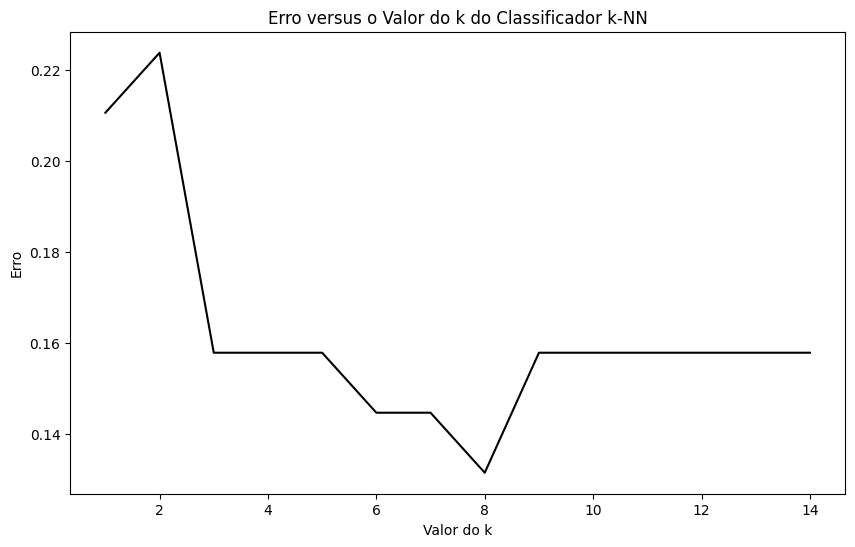

In [7]:
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
erros = []
for i in range (1,15):
    knn = KNeighborsClassifier(n_neighbors = i)
    knn.fit(X_trein, y_trein)
    pred_i = knn.predict(X_teste)
    erros.append(np.mean(pred_i != y_teste))
plt.figure(figsize=(10,6))
plt.plot(range(1,15), erros, color='black')
plt.title('Erro versus o Valor do k do Classificador k-NN')
plt.xlabel('Valor do k')
plt.ylabel('Erro')

Agora que normalizamos os dados qual o valor ótimo de K? Executar o classificador com este valor ótimo de K agora. Melhorou algo?

In [8]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors = 8)
classifier.fit(X_trein, y_trein)
# avaliar o algoritmo novamente
y_pred = classifier.predict(X_teste)
from sklearn.metrics import confusion_matrix, classification_report
print ('\n')
print(confusion_matrix(y_teste, y_pred))
print('\n')
print(classification_report(y_teste, y_pred))



[[27  6]
 [ 4 39]]


              precision    recall  f1-score   support

           0       0.87      0.82      0.84        33
           1       0.87      0.91      0.89        43

    accuracy                           0.87        76
   macro avg       0.87      0.86      0.87        76
weighted avg       0.87      0.87      0.87        76

